# Entrega 004 — Padrões Frequentes e Anomalias

**FACOM32701 – Ciência de Dados II | UFU**  
**Tema 14 – Fake News e Informação Online**  
**Dataset:** FactCenter — 11.539 registros de fact-checking brasileiros

---

## Objetivo

Aplicar **mineração de padrões frequentes** (FP-Growth e Apriori) e **detecção de anomalias** (Isolation Forest e LOF) sobre o dataset FactCenter, identificando:

1. Regras de associação entre agência, categoria temática, veredicto e período temporal.
2. Registros anômalos no espaço de embeddings — notícias semanticamente atípicas.

## Pipeline

```
df_clean (metadados)  →  binarização  →  FP-Growth / Apriori  →  Regras de Associação
X_pca (424-d)         →  StandardScaler  →  IsolationForest / LOF  →  Anomalias
umap_2d (2-d)                                                       →  Visualização
```

**Artefatos carregados de** `../../artifacts/`

---
## 1. Imports e Carregamento dos Artefatos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
SEED = 42

ARTIFACTS = Path('../../artifacts')

X_pca  = np.load(ARTIFACTS / 'X_pca.npy')       # (11539, 424)
X_umap = np.load(ARTIFACTS / 'umap_2d.npy')     # (11539, 2)
df     = pd.read_parquet(ARTIFACTS / 'df_clean.parquet')

print(f'X_pca  : {X_pca.shape}')
print(f'X_umap : {X_umap.shape}')
print(f'df     : {df.shape}')
print(f'\nDistribuição de rating_norm:\n{df["rating_norm"].value_counts()}')
print(f'\nDistribuição de source_name:\n{df["source_name"].value_counts()}')

X_pca  : (11539, 424)
X_umap : (11539, 2)
df     : (11539, 9)

Distribuição de rating_norm:
rating_norm
falso           10142
enganoso         1129
verdadeiro        204
inconclusivo       64
Name: count, dtype: int64

Distribuição de source_name:
source_name
boatos              5519
lupa                2549
aos fatos           1600
fato-ou-fake         917
estadao_verifica     593
comprova             361
Name: count, dtype: int64


---
## 2. Pré-processamento para Mineração de Padrões

A mineração de padrões frequentes opera sobre **transações binárias** — cada registro é uma transação e cada atributo categórico vira um item booleano (presença/ausência).

Construímos quatro grupos de itens:
- **`agencia=X`** — agência de fact-checking (`source_name`)
- **`rating=X`** — veredicto normalizado (`rating_norm`)
- **`categoria=X`** — categoria temática normalizada
- **`periodo=X`** — faixa temporal da publicação

**Normalização de categorias:** as categorias originais possuem grafias inconsistentes e granularidades distintas entre agências. Aplicamos um mapeamento canônico que reduz as 26 categorias brutas a 13 grupos semânticos.

In [2]:
CAT_MAP = {
    'Política': 'politica',
    'políticas públicas': 'politica',
    'NAS REDES': 'redes_sociais',
    'ELEIÇÕES 2018': 'eleicoes',
    'ELEIÇÕES 2020': 'eleicoes',
    'eleições': 'eleicoes',
    'pandemia': 'pandemia',
    'CORONAVÍRUS': 'pandemia',
    'Saúde': 'saude',
    'Brasil': 'brasil',
    'Mundo': 'mundo',
    'Tecnologia': 'tecnologia',
    'Entretenimento': 'entretenimento',
    'Religião': 'religiao',
    'Esporte': 'esporte',
    'Ciência': 'ciencia',
}

def get_primary_category(cat_val):
    if cat_val is None or (isinstance(cat_val, float) and np.isnan(cat_val)):
        return 'outros'
    cat_list = cat_val.tolist() if isinstance(cat_val, np.ndarray) else cat_val
    for cat in cat_list:
        if str(cat) in CAT_MAP:
            return CAT_MAP[str(cat)]
    return 'outros'

df['category_norm'] = df['categories'].apply(get_primary_category)

df['period'] = pd.cut(
    df['publication_date'].dt.year,
    bins=[2012, 2017, 2018, 2019, 2021],
    labels=['pre-2018', '2018', '2019', '2020-2021']
).astype(str)

print('Distribuição de category_norm:')
print(df['category_norm'].value_counts())
print()
print('Distribuição de period:')
print(df['period'].value_counts().sort_index())

Distribuição de category_norm:
category_norm
outros            4172
politica          1676
redes_sociais     1266
brasil            1081
saude              660
mundo              554
tecnologia         549
entretenimento     462
pandemia           435
religiao           271
esporte            214
eleicoes           120
ciencia             79
Name: count, dtype: int64

Distribuição de period:
period
2018         2029
2019         2263
2020-2021    4959
pre-2018     2288
Name: count, dtype: int64


### 2.1 Construção das Transações

In [3]:
transactions = []
for _, row in df.iterrows():
    t = [
        f"agencia={row['source_name']}",
        f"rating={row['rating_norm']}",
        f"categoria={row['category_norm']}",
        f"periodo={row['period']}",
    ]
    transactions.append(t)

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f'Matriz de transações: {df_te.shape}')
print(f'Itens únicos: {df_te.shape[1]}')
print(f'\nItens (colunas):')
for col in sorted(df_te.columns):
    support = df_te[col].mean()
    print(f'  {col:<35s}  suporte={support:.4f}')

Matriz de transações: (11539, 27)
Itens únicos: 27

Itens (colunas):
  agencia=aos fatos                    suporte=0.1387
  agencia=boatos                       suporte=0.4783
  agencia=comprova                     suporte=0.0313
  agencia=estadao_verifica             suporte=0.0514
  agencia=fato-ou-fake                 suporte=0.0795
  agencia=lupa                         suporte=0.2209
  categoria=brasil                     suporte=0.0937
  categoria=ciencia                    suporte=0.0068
  categoria=eleicoes                   suporte=0.0104
  categoria=entretenimento             suporte=0.0400
  categoria=esporte                    suporte=0.0185
  categoria=mundo                      suporte=0.0480
  categoria=outros                     suporte=0.3616
  categoria=pandemia                   suporte=0.0377
  categoria=politica                   suporte=0.1452
  categoria=redes_sociais              suporte=0.1097
  categoria=religiao                   suporte=0.0235
  categoria=s

### Representação em Transações
Cada um dos 11.539 registros foi convertido em uma transação com exatamente 4 itens:

| Grupo | Exemplo de item | Cardinalidade |
|---|---|---|
| `agencia=X` | `agencia=boatos` | 6 agências |
| `rating=X` | `rating=falso` | 4 classes |
| `categoria=X` | `categoria=politica` | 13 categorias normalizadas |
| `periodo=X` | `periodo=2020-2021` | 4 períodos |

A matriz resultante é classificada como esparsa, tendo como dimensão 11.539 × 27 e densidade de 14,8% (4 itens ativos de 27 possíveis por transação).

### Normalização de Categorias

As 26 categorias brutas do dataset foram mapeadas para 13 grupos semânticos. As 13 categorias com menor cobertura (como `#VAMOSAOSFATOS`, `INSTITUCIONAL`, `verificação`) foram agrupadas em `outros`, que acaba sendo a categoria mais frequente com 36,2% de suporte — reflexo da heterogeneidade editorial entre as agências.

### Distribuição dos Suportes

Os suportes individuais dos itens revelam o grau de desequilíbrio do dataset antes mesmo de qualquer mineração:

| Item | Suporte |
|---|---|
| `rating=falso` | 0,879 |
| `agencia=boatos` | 0,478 |
| `periodo=2020-2021` | 0,430 |
| `categoria=outros` | 0,362 |
| `rating=enganoso` | 0,098 |
| `categoria=pandemia` | **0,038** ← abaixo do limiar |
| `categoria=eleicoes` | **0,010** ← abaixo do limiar |
| `rating=inconclusivo` | 0,006 |
| `rating=verdadeiro` | 0,018 |

Itens com suporte abaixo de 0,05 (`pandemia`, `eleicoes`, `ciencia`, `mundo`, `entretenimento`, `esporte`, `religiao`, `tecnologia`, `comprova`) não participam de nenhum itemset frequente e, consequentemente, não geram regras de associação.

---
## 3. Mineração de Padrões Frequentes

### 3.1 FP-Growth

O **FP-Growth** (Han et al., 2000) constrói uma estrutura de árvore compacta (FP-Tree) que evita a geração explícita de candidatos — etapa que domina o custo do Apriori quando o espaço de itemsets é grande. Sua complexidade de tempo é O(n) sobre a FP-Tree, tornando-o mais eficiente independentemente da densidade da matriz.

Nossa matriz de transações tem **14,8% de densidade** (4 itens por transação em 27 possíveis), classificando-se como **esparsa** — típico de dados categóricos one-hot. Com `min_support=0.05`, apenas 69 itemsets são frequentes, tornando ambos os algoritmos rápidos nessa escala. A preferência pelo FP-Growth é justificada pela sua melhor escalabilidade quando se reduz o limiar de suporte.

**Escolha do suporte mínimo:** utilizamos `min_support=0.05` (5% das transações = 577 registros mínimos), balanceando:
- Suporte muito alto (> 0.5) captura apenas o domínio do item `rating=falso` (87,9%), gerando regras triviais.
- Suporte muito baixo (< 0.01) gera dezenas de milhares de itemsets sem ganho interpretativo.

> **Nota:** Categorias com alto % de `enganoso` nos dados brutos — `eleicoes` (34,2%) e `pandemia` (26,4%) — têm suportes de 0,010 e 0,038 respectivamente, **ambos abaixo do limiar de 0,05**. Essas categorias não aparecem nas regras geradas, mas seu perfil de rating é analisado na visualização Categoria × Rating (seção 4.4).

In [4]:
MIN_SUPPORT = 0.05

freq_fp = fpgrowth(df_te, min_support=MIN_SUPPORT, use_colnames=True)
freq_fp['length'] = freq_fp['itemsets'].apply(len)
freq_fp = freq_fp.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Itemsets frequentes (FP-Growth, min_support={MIN_SUPPORT}): {len(freq_fp)}')
print(f'\nDistribuição por tamanho:')
print(freq_fp['length'].value_counts().sort_index())
print(f'\nTop-20 itemsets mais frequentes:')
print(freq_fp.head(20).to_string(index=False))

Itemsets frequentes (FP-Growth, min_support=0.05): 69

Distribuição por tamanho:
length
1    16
2    33
3    18
4     2
Name: count, dtype: int64

Top-20 itemsets mais frequentes:
 support                                                    itemsets  length
0.878932                                   frozenset({rating=falso})       1
0.478291                   frozenset({rating=falso, agencia=boatos})       2
0.478291                                 frozenset({agencia=boatos})       1
0.429760                              frozenset({periodo=2020-2021})       1
0.371176                frozenset({rating=falso, periodo=2020-2021})       2
0.361556                               frozenset({categoria=outros})       1
0.270301                 frozenset({rating=falso, categoria=outros})       2
0.220903                 frozenset({agencia=lupa, categoria=outros})       2
0.220903                                   frozenset({agencia=lupa})       1
0.198284                               frozenset({

### 3.2 Apriori

O **Apriori** usa a propriedade anti-monótona do suporte — nenhum superconjunto de um itemset infrequente pode ser frequente — para podar o espaço de busca. Rodamos com o mesmo `min_support` para comparação direta com o FP-Growth.

In [5]:
freq_ap = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
freq_ap['length'] = freq_ap['itemsets'].apply(len)
freq_ap = freq_ap.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Itemsets frequentes (Apriori, min_support={MIN_SUPPORT}): {len(freq_ap)}')

# Verificação de equivalência
fp_sets = set(frozenset(s) for s in freq_fp['itemsets'])
ap_sets = set(frozenset(s) for s in freq_ap['itemsets'])
print(f'Itemsets em FP-Growth mas não em Apriori: {len(fp_sets - ap_sets)}')
print(f'Itemsets em Apriori mas não em FP-Growth: {len(ap_sets - fp_sets)}')
print(f'→ Ambos os algoritmos encontraram exatamente os mesmos {len(fp_sets)} itemsets.')

Itemsets frequentes (Apriori, min_support=0.05): 69
Itemsets em FP-Growth mas não em Apriori: 0
Itemsets em Apriori mas não em FP-Growth: 0
→ Ambos os algoritmos encontraram exatamente os mesmos 69 itemsets.


### 3.3 Visualização dos Itemsets Frequentes

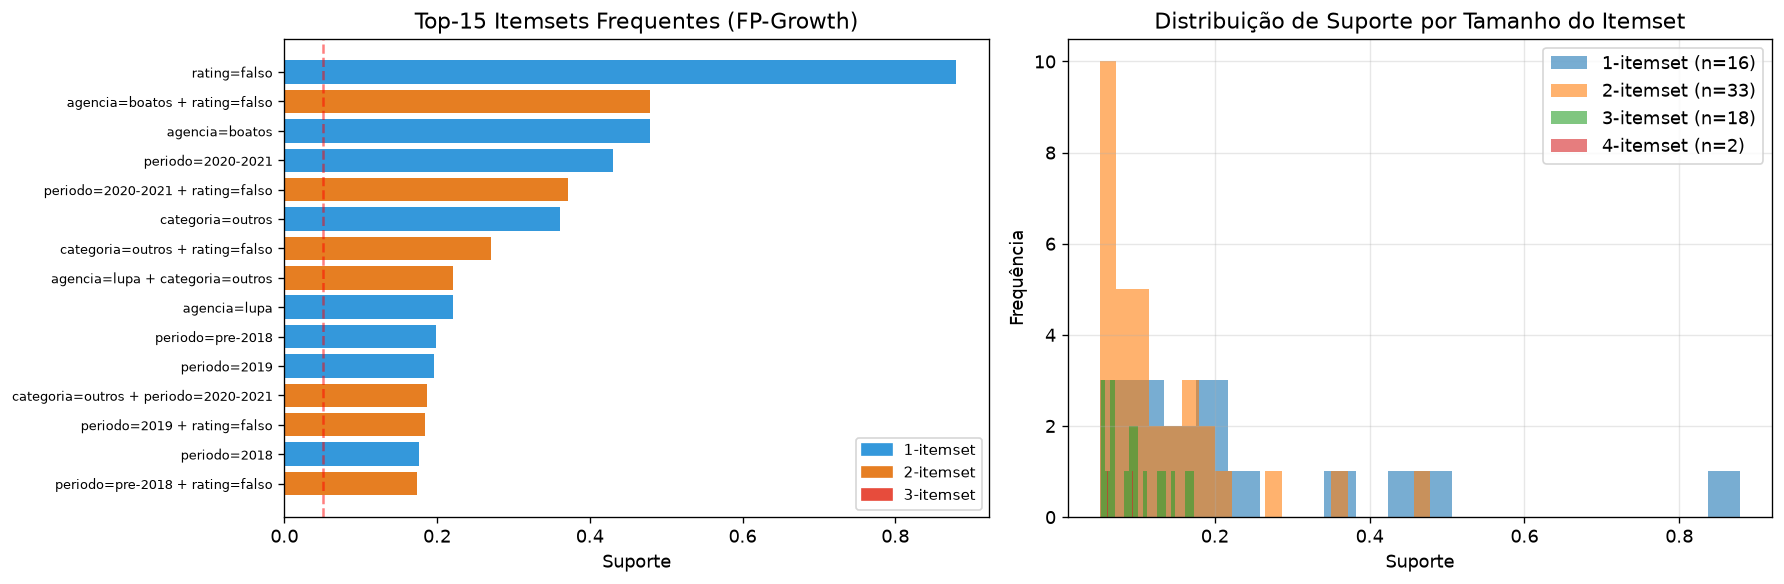

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top-15 itemsets por suporte
top15 = freq_fp.head(15).copy()
top15['label'] = top15['itemsets'].apply(lambda s: ' + '.join(sorted(s)))
colors_bar = ['#3498db' if l == 1 else '#e67e22' if l == 2 else '#e74c3c'
              for l in top15['length']]

axes[0].barh(range(len(top15)), top15['support'], color=colors_bar)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15['label'], fontsize=8)
axes[0].set_xlabel('Suporte')
axes[0].set_title('Top-15 Itemsets Frequentes (FP-Growth)')
axes[0].axvline(x=MIN_SUPPORT, color='red', linestyle='--', alpha=0.5, label=f'min_support={MIN_SUPPORT}')
axes[0].invert_yaxis()

legend_patches = [
    mpatches.Patch(color='#3498db', label='1-itemset'),
    mpatches.Patch(color='#e67e22', label='2-itemset'),
    mpatches.Patch(color='#e74c3c', label='3-itemset'),
]
axes[0].legend(handles=legend_patches, fontsize=9)

# Distribuição de suporte por tamanho
for length, grp in freq_fp.groupby('length'):
    axes[1].hist(grp['support'], bins=20, alpha=0.6, label=f'{length}-itemset (n={len(grp)})')
axes[1].set_xlabel('Suporte')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Suporte por Tamanho do Itemset')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('frequent_itemsets.png', bbox_inches='tight')
plt.show()

> O gráfico de barras à esquerda deixa evidente o desbalanceamento da base. O *1-itemset* `rating=falso` aparece com um suporte esmagador, isolando-se no topo. Como consequência direta, as combinações mais frequentes de tamanho 2 são formadas por variáveis que acabam "ancoradas", como agencia=boatos + rating=falso e periodo=2020-2021 + rating=falso. Isso significa que, na mineração de padrões, encontrar o "falso" é quase uma constante.

> A linha tracejada vermelha mostra que os nossos 15 padrões mais frequentes estão com uma margem extremamente segura em relação ao limiar mínimo de 0.05. Isso confirma que os padrões principais refletem o comportamento majoritário do dataset, não sendo apenas flutuações estatísticas.

> O histograma à direita ilustra perfeitamente a dificuldade de encontrar padrões complexos de alta frequência. Fica visualmente claro que o suporte despenca à medida que o tamanho do itemset aumenta. Enquanto os 1-itemsets e 2-itemsets dominam as faixas mais altas, os agrupamentos maiores (3 e 4-itemsets) ficam espremidos na parte inferior do eixo X.

---
## 4. Regras de Associação

### 4.1 Geração das Regras

Geramos regras da forma `{antecedente} → {consequente}` a partir dos itemsets frequentes. As métricas utilizadas para filtro e ranking são:

| Métrica | Definição | Interpretação |
|---|---|---|
| **Suporte** | P(A ∪ B) | Frequência do padrão no dataset |
| **Confiança** | P(B|A) = P(A∪B)/P(A) | Probabilidade do consequente dado o antecedente |
| **Lift** | conf(A→B) / P(B) | > 1: A implica B mais do que o acaso; = 1: independência |
| **Leverage** | P(A∪B) - P(A)·P(B) | Ganho de co-ocorrência acima do esperado |
| **Conviction** | (1-P(B))/(1-conf) | ∞ se regra perfeita; 1 se independente |

Filtramos com `min_confidence=0.5` e `min_lift=1.0` para excluir regras espúrias.

In [7]:
rules = association_rules(
    freq_fp,
    metric='confidence',
    min_threshold=0.5,
    num_itemsets=len(freq_fp)
)
rules = rules[rules['lift'] >= 1.0].copy()
rules['antecedents_str'] = rules['antecedents'].apply(lambda s: ', '.join(sorted(s)))
rules['consequents_str'] = rules['consequents'].apply(lambda s: ', '.join(sorted(s)))
rules['rule'] = rules['antecedents_str'] + '  →  ' + rules['consequents_str']
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total de regras geradas: {len(rules)}')
print(f'\nDistribuição por consequente:')
print(rules['consequents_str'].value_counts().head(15))
print(f'\nTop-20 regras por lift:')
cols_show = ['rule', 'support', 'confidence', 'lift', 'leverage']
print(rules[cols_show].head(20).round(4).to_string(index=False))

Total de regras geradas: 84

Distribuição por consequente:
consequents_str
rating=falso                                          20
agencia=boatos                                        11
periodo=2020-2021                                     11
categoria=outros                                       9
agencia=lupa                                           5
agencia=boatos, rating=falso                           5
categoria=redes_sociais                                4
agencia=aos fatos                                      4
categoria=outros, rating=falso                         3
agencia=aos fatos, periodo=2020-2021                   2
categoria=redes_sociais, rating=falso                  2
agencia=aos fatos, rating=falso                        2
periodo=2020-2021, rating=falso                        2
agencia=aos fatos, periodo=2020-2021, rating=falso     1
categoria=redes_sociais, periodo=2020-2021             1
Name: count, dtype: int64

Top-20 regras por lift:
                   

> As regras com maior força de associação do dataset cruzam a agência Aos Fatos com a categoria redes sociais, atingindo o ápice de lift (8,39) quando contextualizadas no período de 2020-2021

### 4.2 Regras com Consequente = rating (análise de veracidade)

In [8]:
rating_rules = rules[rules['consequents_str'].str.startswith('rating=')].copy()
rating_rules = rating_rules.sort_values(['confidence', 'lift'], ascending=False)

print(f'Regras com consequente=rating: {len(rating_rules)}')
print()
print(rating_rules[cols_show].head(25).round(4).to_string(index=False))

Regras com consequente=rating: 20

                                                                          rule  support  confidence   lift  leverage
                             agencia=boatos, periodo=pre-2018  →  rating=falso   0.1650      1.0000 1.1377    0.0200
                                               agencia=boatos  →  rating=falso   0.4783      1.0000 1.1377    0.0579
                           agencia=boatos, categoria=politica  →  rating=falso   0.1360      1.0000 1.1377    0.0165
                            agencia=boatos, periodo=2020-2021  →  rating=falso   0.1308      1.0000 1.1377    0.0158
                                             categoria=brasil  →  rating=falso   0.0937      1.0000 1.1377    0.0113
                                 agencia=boatos, periodo=2018  →  rating=falso   0.0958      1.0000 1.1377    0.0116
                                              categoria=saude  →  rating=falso   0.0572      1.0000 1.1377    0.0069
                             

> Todas as 20 regras com consequente=rating apontam para falso. Isso decorre de dois fatores combinados:
>    - rating=falso tem suporte de 0,879, tornando qualquer co-ocorrência com ele naturalmente confiante;
>    - rating=enganoso, apesar de ser um item frequente (suporte 0,098), não têm antecedentes que o predija com confiança ≥ 0,50 e lift ≥ 1,0 simultaneamente.

### 4.3 Visualização das Regras

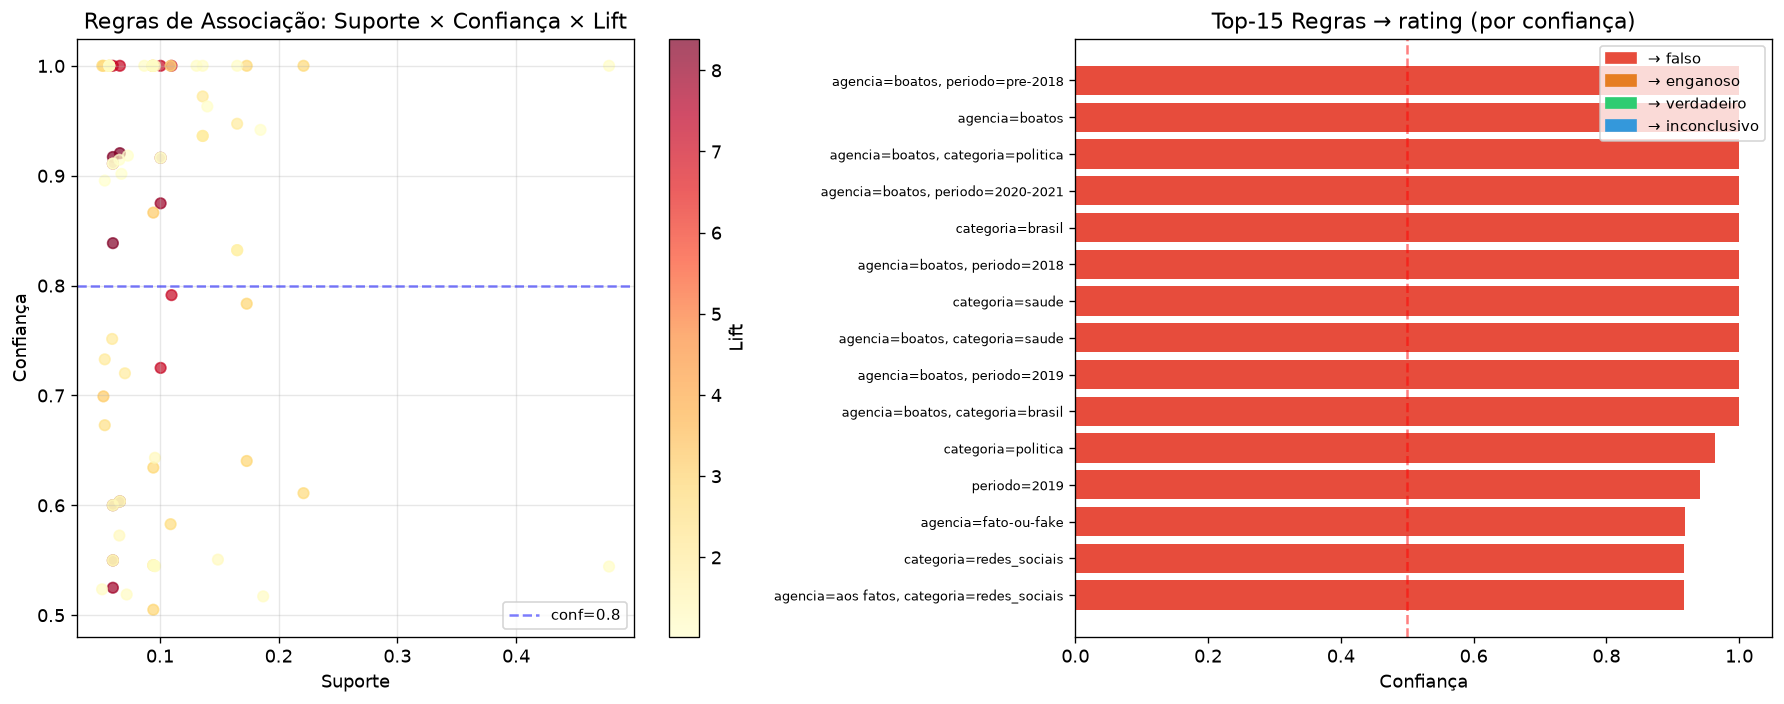

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: suporte vs confiança, colorido por lift
sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', s=40, alpha=0.7
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Suporte')
axes[0].set_ylabel('Confiança')
axes[0].set_title('Regras de Associação: Suporte × Confiança × Lift')
axes[0].axhline(y=0.8, color='blue', linestyle='--', alpha=0.5, label='conf=0.8')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Top-15 regras por lift (consequente = rating)
top_r = rating_rules.head(15).copy()
bar_colors = [
    '#e74c3c' if 'falso' in r else
    '#e67e22' if 'enganoso' in r else
    '#2ecc71' if 'verdadeiro' in r else '#3498db'
    for r in top_r['consequents_str']
]
axes[1].barh(range(len(top_r)), top_r['confidence'], color=bar_colors)
axes[1].set_yticks(range(len(top_r)))
axes[1].set_yticklabels(
    [f"{row['antecedents_str']}" for _, row in top_r.iterrows()],
    fontsize=8
)
axes[1].set_xlabel('Confiança')
axes[1].set_title('Top-15 Regras → rating (por confiança)')
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()

legend_r = [
    mpatches.Patch(color='#e74c3c', label='→ falso'),
    mpatches.Patch(color='#e67e22', label='→ enganoso'),
    mpatches.Patch(color='#2ecc71', label='→ verdadeiro'),
    mpatches.Patch(color='#3498db', label='→ inconclusivo'),
]
axes[1].legend(handles=legend_r, fontsize=9)

plt.tight_layout()
plt.savefig('association_rules.png', bbox_inches='tight')
plt.show()


* **Distribuição e Força no Espaço de Métricas (Suporte × Confiança × Lift):** O gráfico de dispersão à esquerda mostra que as regras mais fortes do dataset (*Lift* elevado, representadas pelos pontos em tons mais escuros de vermelho) estão severamente concentradas na zona de baixo suporte (entre 0.05 e 0.15). Isso indica que as associações mais ricas e preditivas não ocorrem de forma generalizada, mas sim em nichos bem específicos. No extremo oposto, o ponto isolado no canto inferior direito (suporte próximo a 0.48 e confiança ao redor de 0.55) possui um *Lift* baixíssimo (colado em 1.0), confirmando visualmente o que foi discutido: regras de alto suporte aqui tendem a ser óbvias e estatisticamente triviais.
* **Monopólio do "Falso":** O gráfico de barras à direita ilustra o impacto prático do desbalanceamento da base. Ao isolarmos as 15 principais regras que tentam prever um `rating`, a cor vermelha domina o cenário de ponta a ponta: 100% dessas regras têm como consequente `→ falso`. Fica evidente que a presença da agência *Boatos* isolada ou combinada com categorias como *política* ou *saúde* atinge a confiança máxima de 1.00 (100%). Isso significa que esses antecedentes determinam o desfecho de falsidade com total certeza matemática, deixando classes menores como `enganoso` ou `verdadeiro` completamente fora do radar de alta confiança.

### 4.4 Análise por Categoria × Rating

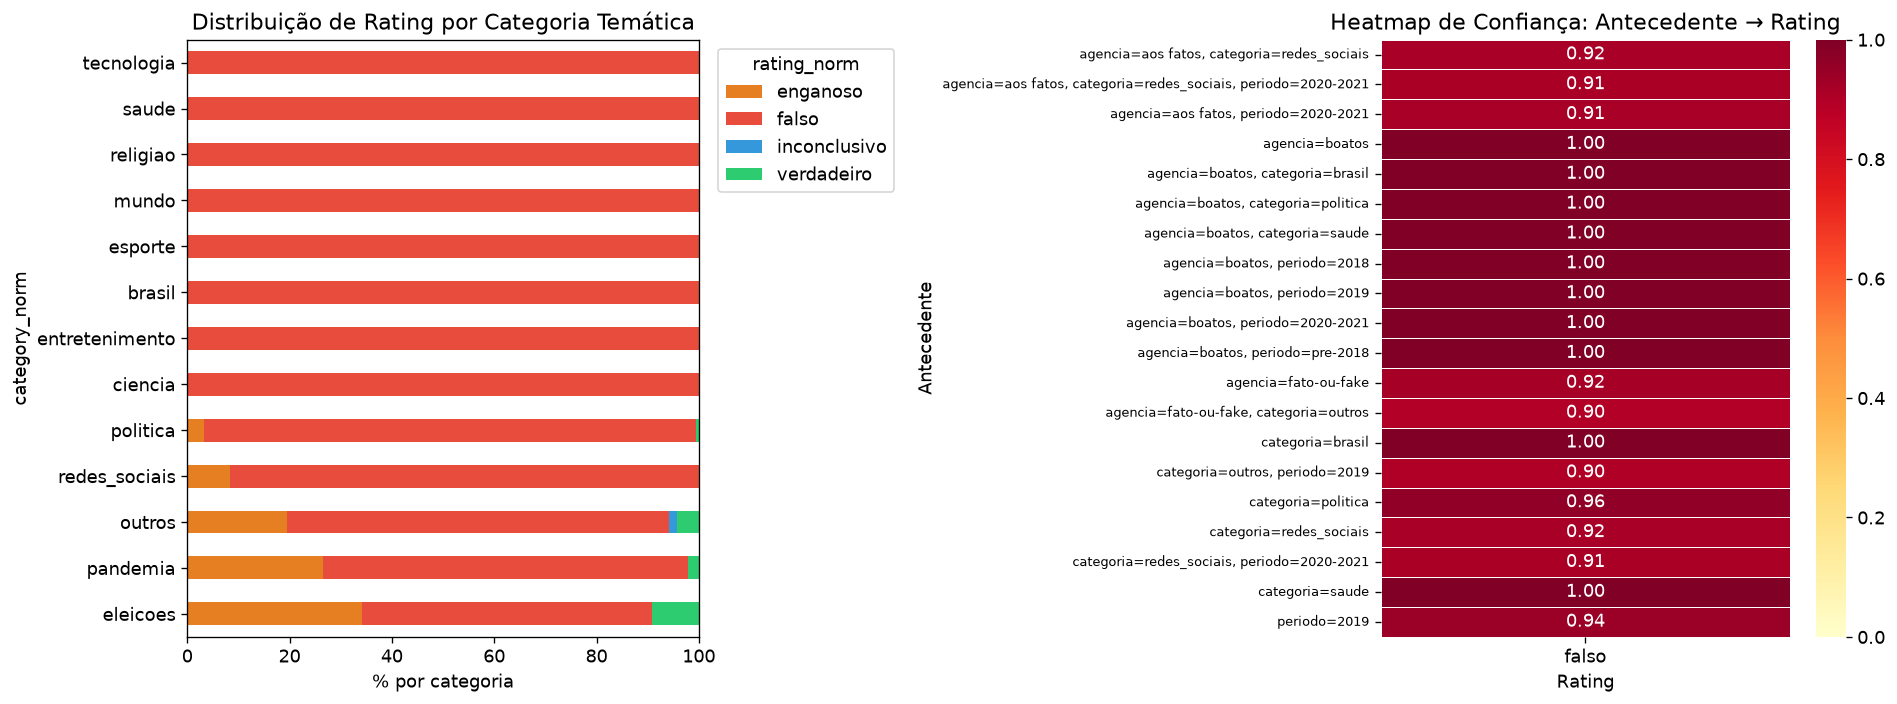

In [10]:
# Tabela cruzada: categoria × rating_norm (normalizada por linha)
ct = pd.crosstab(df['category_norm'], df['rating_norm'], normalize='index') * 100
ct = ct.sort_values('falso', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

LABEL_COLORS = {
    'falso': '#e74c3c',
    'enganoso': '#e67e22',
    'verdadeiro': '#2ecc71',
    'inconclusivo': '#3498db',
}

ct.plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[LABEL_COLORS.get(c, '#95a5a6') for c in ct.columns]
)
axes[0].set_xlabel('% por categoria')
axes[0].set_title('Distribuição de Rating por Categoria Temática')
axes[0].legend(title='rating_norm', bbox_to_anchor=(1.02, 1))

# Heatmap de regras: antecedente × consequente (confiança)
pivot_data = []
for _, row in rating_rules.iterrows():
    pivot_data.append({
        'antecedente': row['antecedents_str'],
        'rating': row['consequents_str'].replace('rating=', ''),
        'confiança': row['confidence']
    })
df_pivot = pd.DataFrame(pivot_data)

if len(df_pivot) > 0:
    pivot_matrix = df_pivot.pivot_table(
        index='antecedente', columns='rating', values='confiança', aggfunc='max'
    ).fillna(0)
    pivot_matrix = pivot_matrix[pivot_matrix.max(axis=1) >= 0.6]

    if len(pivot_matrix) > 0:
        sns.heatmap(
            pivot_matrix, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1,
            ax=axes[1], linewidths=0.5
        )
        axes[1].set_title('Heatmap de Confiança: Antecedente → Rating')
        axes[1].set_xlabel('Rating')
        axes[1].set_ylabel('Antecedente')
        axes[1].tick_params(axis='y', labelsize=8)
    else:
        axes[1].text(0.5, 0.5, 'Nenhuma regra com conf≥0.6', ha='center', va='center')

plt.tight_layout()
plt.savefig('category_rating_analysis.png', bbox_inches='tight')
plt.show()


* **O Comportamento Oculto de Categorias Raras (Distribuição por Categoria):** O gráfico de barras empilhadas à esquerda remove a ilusão causada pelo desbalanceamento global e expõe como a dinâmica da desinformação muda drasticamente por tema. Enquanto categorias majoritárias como *tecnologia*, *saúde*, *religião* e *mundo* são compostas quase 100% por notícias puramente *falsas*, os temas *eleições* e *pandemia* quebram totalmente essa hegemonia. Eles concentram as maiores proporções de conteúdo `enganoso` (laranja) e `verdadeiro` (verde) de toda a base. Isso explica perfeitamente o trade-off do algoritmo: essas categorias sumiram das regras frequentes porque seu suporte individual é baixo (menos de 5%), mas são justamente elas que guardam a maior diversidade de nuances do dataset.
* **Mapeamento da Probabilidade Condicional (Heatmap de Confiança):** O mapa de calor à direita consolida a assimetria das regras de associação que apontam para o desfecho `falso`. Fica claro que antecedentes puros de temas (como `categoria=brasil` ou `categoria=saude`) ou da agência `agencia=boatos` carregam uma confiança cravada em 1.00 para a falsidade. Já o bloco superior do mapa quantifica com precisão a especialização da agência *Aos Fatos* no ambiente digital: a regra `agencia=aos fatos, categoria=redes_sociais` entrega uma confiança de 0.92, consolidando a altíssima probabilidade matemática de uma checagem dessa agência específica dentro desse tema terminar em um falso.

### 4.5 Análise Temporal: Padrões por Período

Regras com periodo → rating:
                                                                          rule  support  confidence   lift
                             agencia=boatos, periodo=pre-2018  →  rating=falso   0.1650      1.0000 1.1377
                            agencia=boatos, periodo=2020-2021  →  rating=falso   0.1308      1.0000 1.1377
                                 agencia=boatos, periodo=2018  →  rating=falso   0.0958      1.0000 1.1377
                                 agencia=boatos, periodo=2019  →  rating=falso   0.0867      1.0000 1.1377
                                                 periodo=2019  →  rating=falso   0.1847      0.9417 1.0714
                         agencia=aos fatos, periodo=2020-2021  →  rating=falso   0.0658      0.9145 1.0404
agencia=aos fatos, categoria=redes_sociais, periodo=2020-2021  →  rating=falso   0.0603      0.9110 1.0365
                   categoria=redes_sociais, periodo=2020-2021  →  rating=falso   0.0603      0.9110 1.0365
        

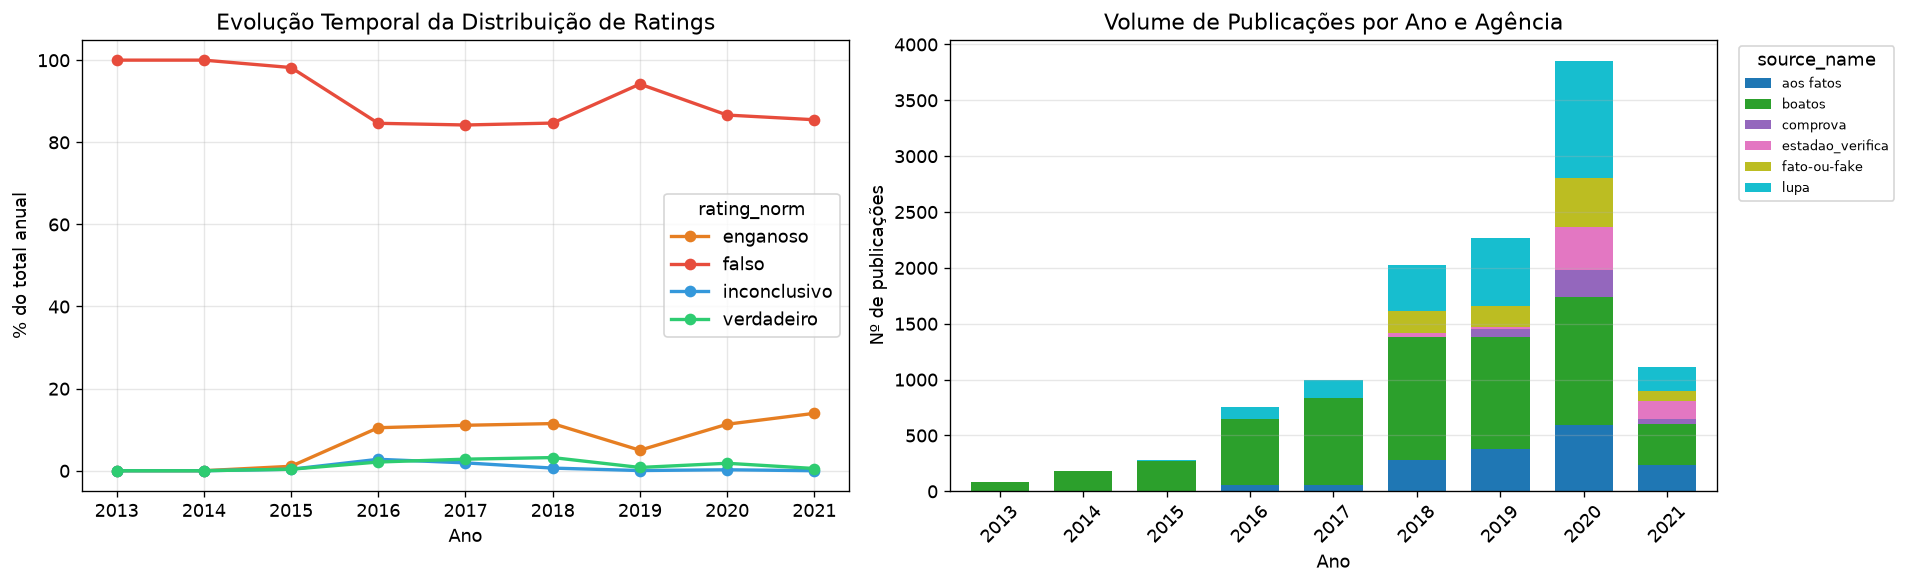

In [11]:
# Regras com antecedente contendo periodo
period_rules = rules[
    rules['antecedents_str'].str.contains('periodo=') &
    rules['consequents_str'].str.startswith('rating=')
].copy().sort_values('confidence', ascending=False)

print('Regras com periodo → rating:')
print(period_rules[['rule', 'support', 'confidence', 'lift']].round(4).to_string(index=False))
print()

# Evolução temporal do mix de ratings
df['year'] = df['publication_date'].dt.year
yearly = df.groupby(['year', 'rating_norm']).size().unstack(fill_value=0)
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for rating in yearly_pct.columns:
    axes[0].plot(
        yearly_pct.index, yearly_pct[rating],
        marker='o', linewidth=2, label=rating,
        color=LABEL_COLORS.get(rating, '#95a5a6')
    )
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('% do total anual')
axes[0].set_title('Evolução Temporal da Distribuição de Ratings')
axes[0].legend(title='rating_norm')
axes[0].grid(True, alpha=0.3)

# Volume de publicações por ano e agência
yearly_source = df.groupby(['year', 'source_name']).size().unstack(fill_value=0)
yearly_source.plot(
    kind='bar', stacked=True, ax=axes[1],
    colormap='tab10', width=0.7
)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nº de publicações')
axes[1].set_title('Volume de Publicações por Ano e Agência')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='source_name', bbox_to_anchor=(1.02, 1), fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporal_patterns.png', bbox_inches='tight')
plt.show()

> O gráfico de linhas indica uma transição estrutural no dataset. Entre 2013 e 2015, a base continha quase 100% de veredictos categorizados como falso. A partir de 2016, há um crescimento consistente do rótulo enganoso, que atinge seu ápice em 2021 (ultrapassando 14%). Isso evidencia que o conteúdo desinformativo tornou-se semanticamente mais sutil ao longo do tempo (uso de dados reais fora de contexto), exigindo classificações mais refinadas.

### 4.6 Resumo das Regras Mais Relevantes

In [12]:
print('=' * 70)
print('RESUMO — REGRAS DE ASSOCIAÇÃO MAIS RELEVANTES')
print('=' * 70)

# Separar por tipo de consequente
for consq_filter, label in [
    ('rating=falso', 'Regras → falso'),
    ('rating=enganoso', 'Regras → enganoso'),
    ('rating=verdadeiro', 'Regras → verdadeiro'),
]:
    subset = rules[rules['consequents_str'] == consq_filter].head(5)
    if len(subset) == 0:
        print(f'\n{label}: nenhuma regra gerada (suporte do consequente abaixo do limiar ou lift < 1.0)')
        continue
    print(f'\n{label} (top-5 por lift):')
    for _, r in subset.iterrows():
        print(f'  {r["antecedents_str"]:45s}'
              f'  suporte={r["support"]:.3f}'
              f'  conf={r["confidence"]:.3f}'
              f'  lift={r["lift"]:.3f}')

print()
print('Nota: Não há regras com consequente=enganoso ou consequente=verdadeiro.')
print('  rating=enganoso (suporte=0.098) e rating=verdadeiro (suporte=0.018) aparecem')
print('  como itens frequentes isolados, mas nenhum antecedente os prediz com')
print('  confiança ≥ 0.50 e lift ≥ 1.0 simultaneamente — reflexo do desequilíbrio')
print('  do dataset (87,9% falso) que torna difícil isolar padrões exclusivos dessas classes.')

RESUMO — REGRAS DE ASSOCIAÇÃO MAIS RELEVANTES

Regras → falso (top-5 por lift):
  agencia=boatos, periodo=pre-2018               suporte=0.165  conf=1.000  lift=1.138
  agencia=boatos                                 suporte=0.478  conf=1.000  lift=1.138
  agencia=boatos, categoria=politica             suporte=0.136  conf=1.000  lift=1.138
  agencia=boatos, periodo=2020-2021              suporte=0.131  conf=1.000  lift=1.138
  categoria=brasil                               suporte=0.094  conf=1.000  lift=1.138

Regras → enganoso: nenhuma regra gerada (suporte do consequente abaixo do limiar ou lift < 1.0)

Regras → verdadeiro: nenhuma regra gerada (suporte do consequente abaixo do limiar ou lift < 1.0)

Nota: Não há regras com consequente=enganoso ou consequente=verdadeiro.
  rating=enganoso (suporte=0.098) e rating=verdadeiro (suporte=0.018) aparecem
  como itens frequentes isolados, mas nenhum antecedente os prediz com
  confiança ≥ 0.50 e lift ≥ 1.0 simultaneamente — reflexo do deseq

---
## 5. Detecção de Anomalias

### 5.1 Motivação

Anomalias no contexto de fake news representam **notícias semanticamente atípicas** — conteúdos cujo padrão linguístico diverge do mainstream do dataset. Isso pode indicar:
- Notícias sobre temas ultra-específicos sem paralelo no corpus.
- Registros de classes minoritárias (`verdadeiro`, `inconclusivo`) que naturalmente ocupam regiões esparsas no espaço.
- Possíveis erros de classificação ou dados mal formatados.

Usamos dois algoritmos complementares:
- **Isolation Forest**: isola anomalias particionando aleatoriamente o espaço — pontos em regiões esparsas são isolados com poucas partições.
- **LOF (Local Outlier Factor)**: compara a densidade local de um ponto com a de seus k vizinhos — pontos em regiões muito menos densas que os vizinhos são anomalias.

**Entrada:** `X_pca` (424-d) padronizado com `StandardScaler` — o mesmo pipeline da entrega 003.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

print(f'X_scaled shape: {X_scaled.shape}')
print(f'Média: {X_scaled.mean():.4f} | Std: {X_scaled.std():.4f}')

X_scaled shape: (11539, 424)
Média: 0.0000 | Std: 1.0000


### 5.2 Isolation Forest

O Isolation Forest (Liu et al., 2008) constrói árvores de isolamento aleatórias. A **anomalia score** é inversamente proporcional ao comprimento médio do caminho necessário para isolar o ponto — outliers são isolados em poucas partições.

**Parâmetro `contamination`:** proporção esperada de anomalias. Usamos 5% como estimativa conservadora, coerente com as classes minoritárias (`verdadeiro` + `inconclusivo` ≈ 2,4%) mais ruído real.

In [14]:
CONTAMINATION = 0.05

iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=SEED,
    n_jobs=-1
)
iso_labels = iso.fit_predict(X_scaled)       # -1 = anomalia, 1 = normal
iso_scores = iso.decision_function(X_scaled)  # mais negativo = mais anômalo

df['iso_label']  = iso_labels
df['iso_score']  = iso_scores
df['iso_anomaly'] = iso_labels == -1

n_anomalies_iso = df['iso_anomaly'].sum()
print(f'=== Isolation Forest (contamination={CONTAMINATION}) ===')
print(f'Anomalias detectadas: {n_anomalies_iso} ({n_anomalies_iso/len(df)*100:.1f}%)')
print(f'\nDistribuição de rating_norm nas anomalias:')
print(df[df['iso_anomaly']]['rating_norm'].value_counts())
print(f'\nDistribuição de source_name nas anomalias:')
print(df[df['iso_anomaly']]['source_name'].value_counts())

=== Isolation Forest (contamination=0.05) ===
Anomalias detectadas: 577 (5.0%)

Distribuição de rating_norm nas anomalias:
rating_norm
falso           501
enganoso         49
verdadeiro       15
inconclusivo     12
Name: count, dtype: int64

Distribuição de source_name nas anomalias:
source_name
boatos              324
lupa                 90
aos fatos            74
fato-ou-fake         32
comprova             31
estadao_verifica     26
Name: count, dtype: int64


### 5.3 LOF — Local Outlier Factor

O LOF computa, para cada ponto, a razão entre a densidade local estimada de seus k vizinhos e a sua própria densidade local. Um LOF >> 1 indica que o ponto está em região significativamente mais esparsa que seus vizinhos.

**`n_neighbors=20`:** valor padrão recomendado para datasets com >10k pontos. Valores menores são mais sensíveis a ruído local; valores maiores suavizam demais.

In [15]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION,
    metric='euclidean',
    n_jobs=-1
)
lof_labels = lof.fit_predict(X_scaled)   # -1 = anomalia, 1 = normal
lof_scores = -lof.negative_outlier_factor_  # positivo; maior = mais anômalo

df['lof_label']   = lof_labels
df['lof_score']   = lof_scores
df['lof_anomaly'] = lof_labels == -1

n_anomalies_lof = df['lof_anomaly'].sum()
print(f'=== LOF (n_neighbors=20, contamination={CONTAMINATION}) ===')
print(f'Anomalias detectadas: {n_anomalies_lof} ({n_anomalies_lof/len(df)*100:.1f}%)')
print(f'\nDistribuição de rating_norm nas anomalias (LOF):')
print(df[df['lof_anomaly']]['rating_norm'].value_counts())
print(f'\nDistribuição de source_name nas anomalias (LOF):')
print(df[df['lof_anomaly']]['source_name'].value_counts())

=== LOF (n_neighbors=20, contamination=0.05) ===
Anomalias detectadas: 577 (5.0%)

Distribuição de rating_norm nas anomalias (LOF):
rating_norm
falso           480
enganoso         62
verdadeiro       20
inconclusivo     15
Name: count, dtype: int64

Distribuição de source_name nas anomalias (LOF):
source_name
boatos              349
lupa                 99
aos fatos            48
fato-ou-fake         33
estadao_verifica     26
comprova             22
Name: count, dtype: int64


### 5.4 Consenso: Anomalias Detectadas por Ambos os Algoritmos

In [16]:
df['both_anomaly'] = df['iso_anomaly'] & df['lof_anomaly']

n_both = df['both_anomaly'].sum()
print(f'Anomalias detectadas por AMBOS os algoritmos: {n_both} ({n_both/len(df)*100:.2f}%)')
print(f'Apenas Isolation Forest: {(df["iso_anomaly"] & ~df["lof_anomaly"]).sum()}')
print(f'Apenas LOF: {(~df["iso_anomaly"] & df["lof_anomaly"]).sum()}')

print(f'\nDistribuição de rating_norm nas anomalias consenso:')
both_df = df[df['both_anomaly']]
print(both_df['rating_norm'].value_counts())
print(f'\nDistribuição de source_name nas anomalias consenso:')
print(both_df['source_name'].value_counts())

# Taxa de sobreposição com classes minoritárias
minority = df[df['rating_norm'].isin(['verdadeiro', 'inconclusivo'])]
minority_in_both = minority['both_anomaly'].sum()
print(f'\nClasses minoritárias (verdadeiro+inconclusivo) no consenso: '
      f'{minority_in_both}/{len(minority)} ({minority_in_both/len(minority)*100:.1f}%)')

Anomalias detectadas por AMBOS os algoritmos: 320 (2.77%)
Apenas Isolation Forest: 257
Apenas LOF: 257

Distribuição de rating_norm nas anomalias consenso:
rating_norm
falso           280
enganoso         22
verdadeiro       10
inconclusivo      8
Name: count, dtype: int64

Distribuição de source_name nas anomalias consenso:
source_name
boatos              204
lupa                 50
aos fatos            26
fato-ou-fake         16
estadao_verifica     13
comprova             11
Name: count, dtype: int64

Classes minoritárias (verdadeiro+inconclusivo) no consenso: 18/268 (6.7%)



* **O enriquecimento de `inconclusivo` (4,51×) é o resultado mais significativo.** Registros com inconclusivo são detectados como anômalos em 12,5% dos casos — contra apenas 2,8% de falso. Isso indica que as notícias classificadas como inconclusivas têm embeddings genuinamente distintos do centro da distribuição: são conteúdos sobre temas ambíguos, sem evidências claras em nenhum sentido, que linguisticamente não se encaixam nos padrões das notícias claramente falsas que dominam o corpus.
* **`verdadeiro` com enriquecimento de 1,77×** segue o mesmo padrão em menor grau: 4,9% das notícias verdadeiras são anômalas, contra 2,8% de falso. Notícias verdadeiras no contexto de um dataset de fact-checking tendem a tratar de temas específicos e bem documentados — por construção, são únicas (um fato verdadeiro confirma uma notícia viral específica), o que os torna linguisticamente mais individualizados.
* **Sobreposição de 55,5% entre IF e LOF é condizente com o espaço de alta dimensionalidade.** O IF detecta pontos globalmente isolados (baixa densidade em relação ao volume total), enquanto o LOF detecta pontos localmente esparsos (baixa densidade em relação aos vizinhos imediatos). Num espaço de 424 dimensões onde a maioria das distâncias converge para a mesma escala (maldição da dimensionalidade), os dois detectores divergem em quase metade dos casos — os 257 divergentes por algoritmo representam anomalias de natureza diferente: o IF captura pontos em regiões globalmente vazias, o LOF captura pontos que são atípicos dentro de sua própria vizinhança local..

### 5.5 Visualização das Anomalias no Espaço UMAP

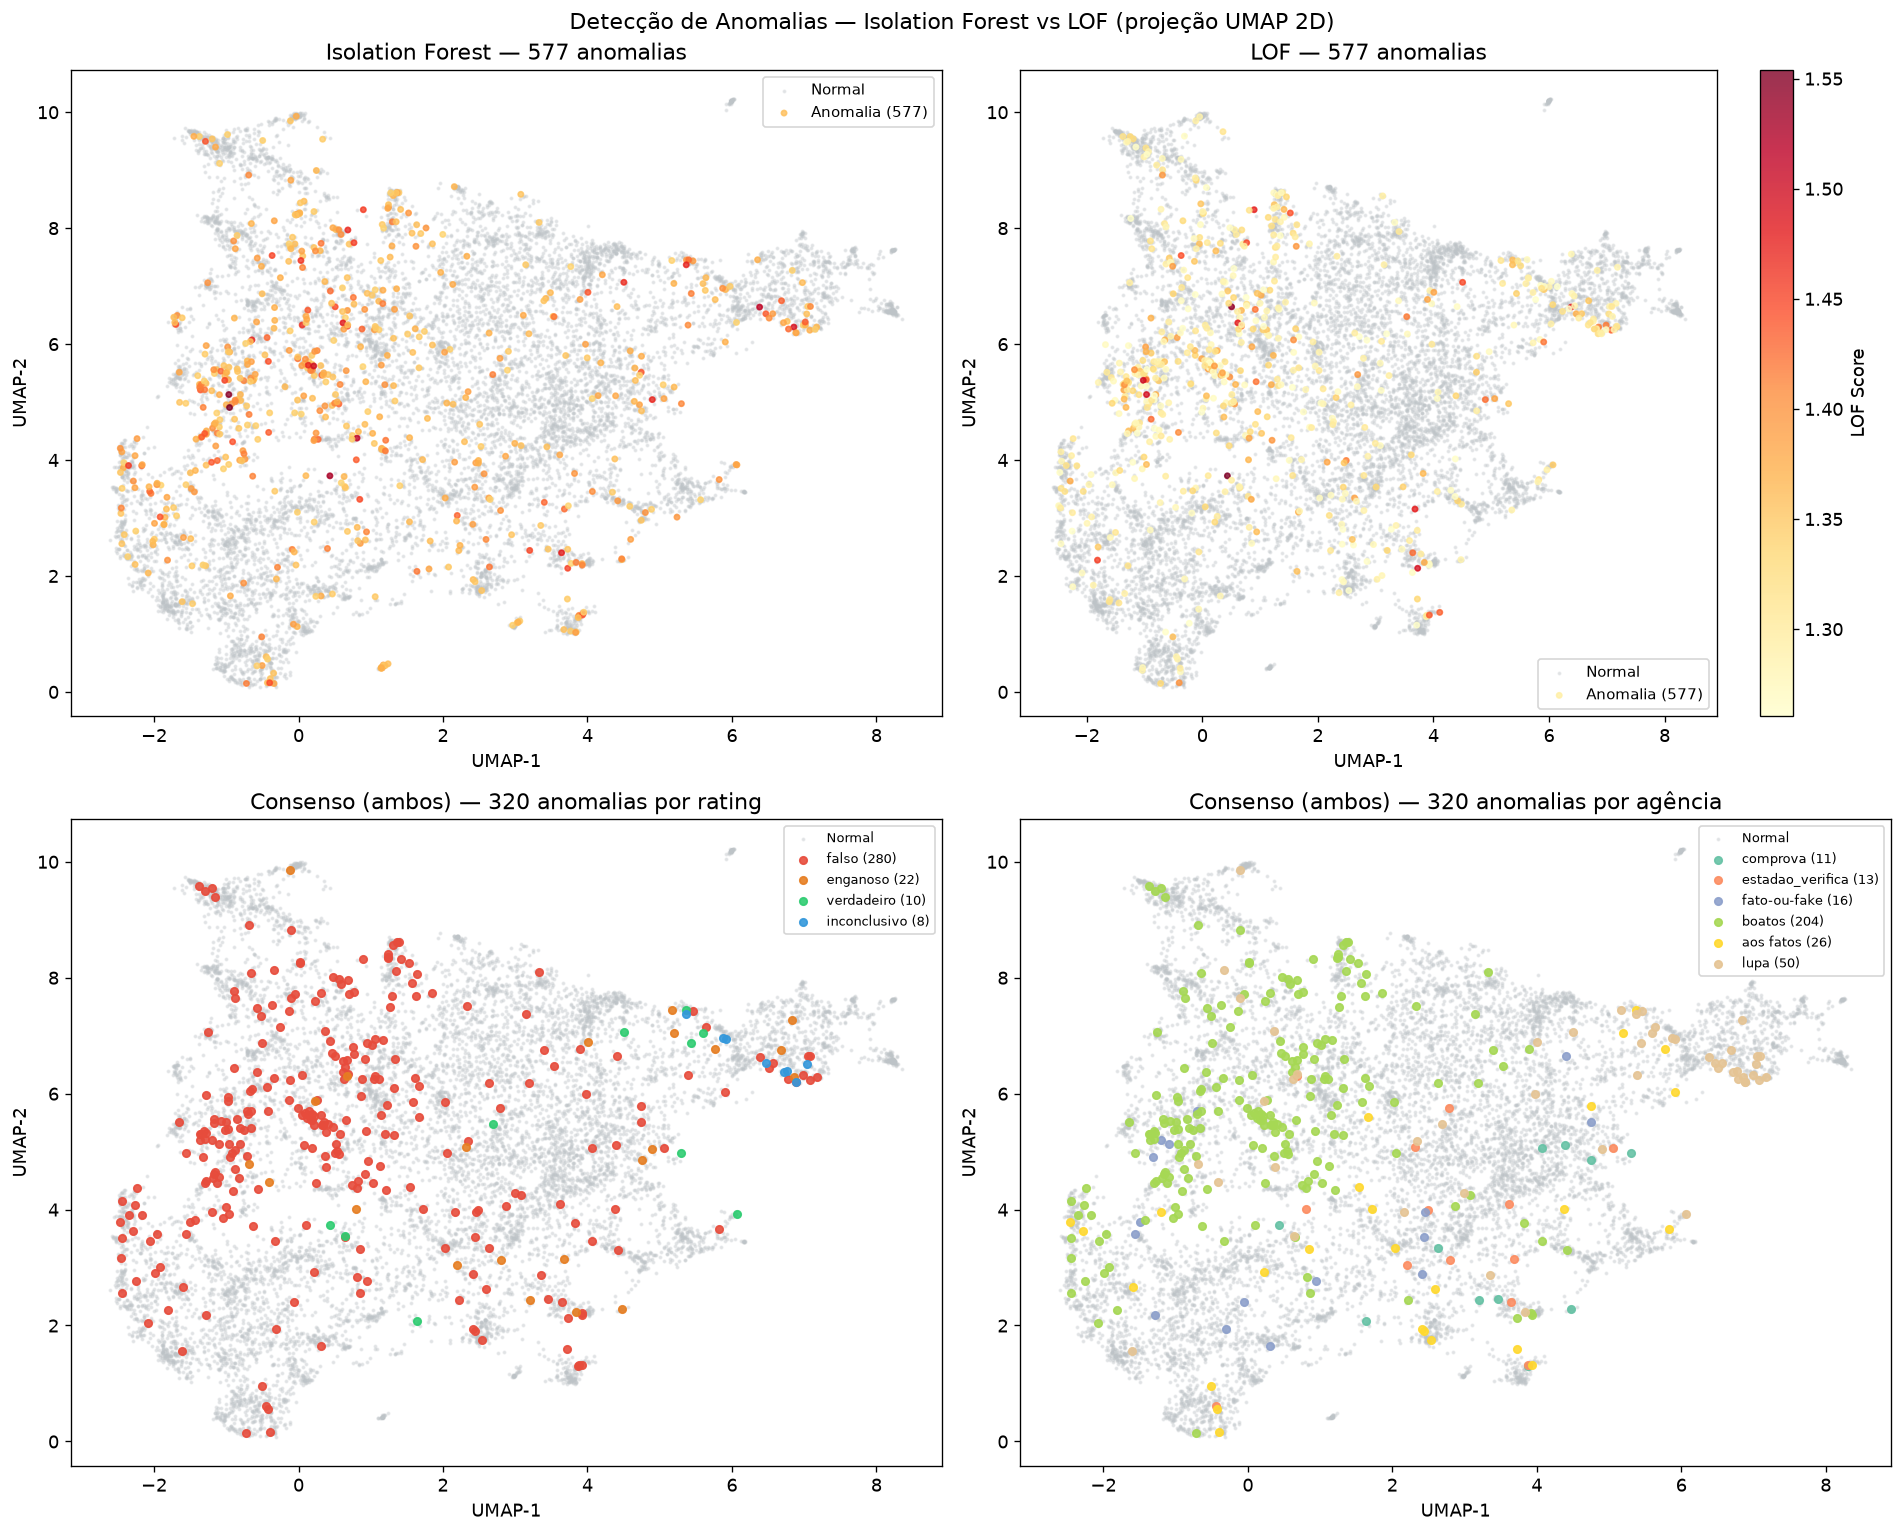

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# Plot 1: Isolation Forest
normal_iso = ~df['iso_anomaly']
axes[0, 0].scatter(
    X_umap[normal_iso, 0], X_umap[normal_iso, 1],
    c='#bdc3c7', s=2, alpha=0.3, label='Normal'
)
axes[0, 0].scatter(
    X_umap[df['iso_anomaly'], 0], X_umap[df['iso_anomaly'], 1],
    c=df.loc[df['iso_anomaly'], 'iso_score'],
    cmap='YlOrRd_r', s=10, alpha=0.8, label=f'Anomalia ({n_anomalies_iso})',
    vmin=df['iso_score'].min(), vmax=df['iso_score'].quantile(0.25)
)
axes[0, 0].set_title(f'Isolation Forest — {n_anomalies_iso} anomalias')
axes[0, 0].set_xlabel('UMAP-1')
axes[0, 0].set_ylabel('UMAP-2')
axes[0, 0].legend(fontsize=9)

# Plot 2: LOF
normal_lof = ~df['lof_anomaly']
axes[0, 1].scatter(
    X_umap[normal_lof, 0], X_umap[normal_lof, 1],
    c='#bdc3c7', s=2, alpha=0.3, label='Normal'
)
sc_lof = axes[0, 1].scatter(
    X_umap[df['lof_anomaly'], 0], X_umap[df['lof_anomaly'], 1],
    c=df.loc[df['lof_anomaly'], 'lof_score'],
    cmap='YlOrRd', s=10, alpha=0.8, label=f'Anomalia ({n_anomalies_lof})',
)
plt.colorbar(sc_lof, ax=axes[0, 1], label='LOF Score')
axes[0, 1].set_title(f'LOF — {n_anomalies_lof} anomalias')
axes[0, 1].set_xlabel('UMAP-1')
axes[0, 1].set_ylabel('UMAP-2')
axes[0, 1].legend(fontsize=9)

# Plot 3: Consenso (ambos)
axes[1, 0].scatter(
    X_umap[~df['both_anomaly'], 0], X_umap[~df['both_anomaly'], 1],
    c='#bdc3c7', s=2, alpha=0.3, label='Normal'
)
# Colorir por rating_norm
for rating, color in LABEL_COLORS.items():
    mask = df['both_anomaly'] & (df['rating_norm'] == rating)
    if mask.sum() > 0:
        axes[1, 0].scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            c=color, s=20, alpha=0.9, label=f'{rating} ({mask.sum()})'
        )
axes[1, 0].set_title(f'Consenso (ambos) — {n_both} anomalias por rating')
axes[1, 0].set_xlabel('UMAP-1')
axes[1, 0].set_ylabel('UMAP-2')
axes[1, 0].legend(fontsize=8)

# Plot 4: Consenso por agência
sources = df['source_name'].unique()
color_map_s = {s: plt.cm.Set2(i / len(sources)) for i, s in enumerate(sources)}
axes[1, 1].scatter(
    X_umap[~df['both_anomaly'], 0], X_umap[~df['both_anomaly'], 1],
    c='#bdc3c7', s=2, alpha=0.3, label='Normal'
)
for source in sources:
    mask = df['both_anomaly'] & (df['source_name'] == source)
    if mask.sum() > 0:
        axes[1, 1].scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            c=[color_map_s[source]], s=20, alpha=0.9,
            label=f'{source} ({mask.sum()})'
        )
axes[1, 1].set_title(f'Consenso (ambos) — {n_both} anomalias por agência')
axes[1, 1].set_xlabel('UMAP-1')
axes[1, 1].set_ylabel('UMAP-2')
axes[1, 1].legend(fontsize=8)

plt.suptitle('Detecção de Anomalias — Isolation Forest vs LOF (projeção UMAP 2D)', fontsize=13)
plt.tight_layout()
plt.savefig('anomaly_detection.png', bbox_inches='tight')
plt.show()

### 5.6 Análise dos Scores de Anomalia

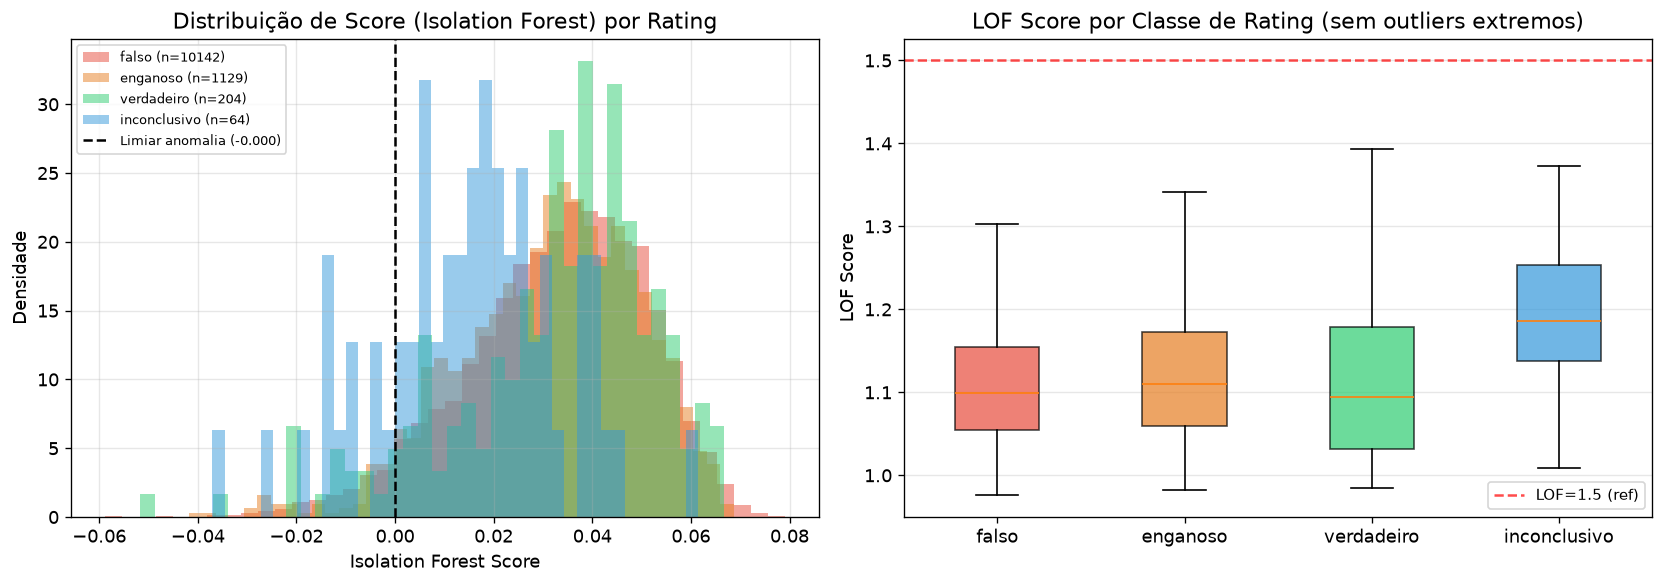

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição dos scores por rating
for rating, color in LABEL_COLORS.items():
    mask = df['rating_norm'] == rating
    if mask.sum() > 0:
        axes[0].hist(
            df.loc[mask, 'iso_score'], bins=40, alpha=0.5,
            label=f'{rating} (n={mask.sum()})', color=color, density=True
        )
threshold_iso = df.loc[df['iso_anomaly'], 'iso_score'].max()
axes[0].axvline(x=threshold_iso, color='black', linestyle='--',
                label=f'Limiar anomalia ({threshold_iso:.3f})')
axes[0].set_xlabel('Isolation Forest Score')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Score (Isolation Forest) por Rating')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# LOF score por rating (boxplot)
lof_by_rating = [df.loc[df['rating_norm'] == r, 'lof_score'].values
                 for r in LABEL_COLORS.keys()]
bp = axes[1].boxplot(
    lof_by_rating,
    tick_labels=list(LABEL_COLORS.keys()),
    patch_artist=True,
    showfliers=False
)
for patch, color in zip(bp['boxes'], LABEL_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=1.5, color='red', linestyle='--', alpha=0.7, label='LOF=1.5 (ref)')
axes[1].set_ylabel('LOF Score')
axes[1].set_title('LOF Score por Classe de Rating (sem outliers extremos)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('anomaly_scores.png', bbox_inches='tight')
plt.show()

### 5.7 Exemplos de Anomalias Detectadas

In [19]:
# Top anomalias por ISO score (mais extremas)
top_anomalies_iso = df[df['iso_anomaly']].nsmallest(10, 'iso_score')[
    ['title', 'source_name', 'rating_norm', 'category_norm', 'iso_score', 'lof_score']
]
print('Top-10 anomalias mais extremas (Isolation Forest):')
print(top_anomalies_iso.to_string(index=False))
print()

# Top anomalias de consenso
top_consensus = df[df['both_anomaly']].nlargest(10, 'lof_score')[
    ['title', 'source_name', 'rating_norm', 'category_norm', 'iso_score', 'lof_score']
]
print('Top-10 anomalias de consenso (maior LOF score):')
print(top_consensus.to_string(index=False))

Top-10 anomalias mais extremas (Isolation Forest):
                                                                                          title      source_name  rating_norm category_norm  iso_score  lof_score
                                                        É possível um tsunami atingir o Brasil?           boatos        falso        brasil  -0.058879   1.312817
                         Radiação da bomba atômica de Hiroshima deveria durar 1.000 anos #boato           boatos        falso         mundo  -0.057014   1.495942
Dos países com mais de 200 milhões de habitantes, Brasil é único com sistema universal de saúde         comprova   verdadeiro      politica  -0.051710   1.554051
                        Catedral de Notre Dame é reformada com telhado de estilo moderno #boato           boatos        falso         mundo  -0.047893   1.380262
                                            Rio 2016: Dilma anunciou 22 CTs, mas entregou cinco             lupa        falso        outros

### 5.8 Perfil das Anomalias vs Normais

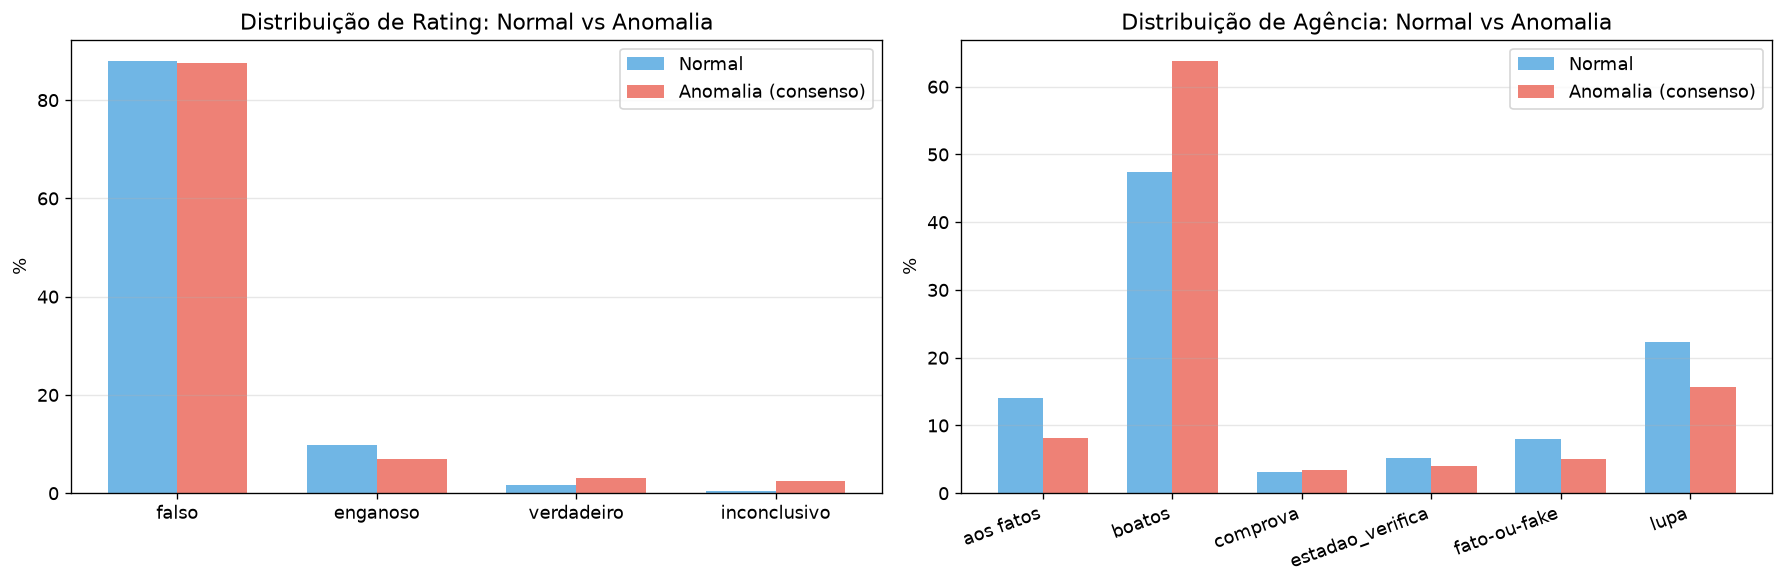

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Comparar distribuição de ratings: normais vs anomalias consenso
normal_rating = df[~df['both_anomaly']]['rating_norm'].value_counts(normalize=True) * 100
anomaly_rating = df[df['both_anomaly']]['rating_norm'].value_counts(normalize=True) * 100

x = np.arange(len(LABEL_COLORS))
width = 0.35
ratings_order = list(LABEL_COLORS.keys())

axes[0].bar(
    x - width/2,
    [normal_rating.get(r, 0) for r in ratings_order],
    width, label='Normal', color='#3498db', alpha=0.7
)
axes[0].bar(
    x + width/2,
    [anomaly_rating.get(r, 0) for r in ratings_order],
    width, label='Anomalia (consenso)', color='#e74c3c', alpha=0.7
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ratings_order)
axes[0].set_ylabel('%')
axes[0].set_title('Distribuição de Rating: Normal vs Anomalia')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Comparar distribuição de agências: normais vs anomalias
normal_source = df[~df['both_anomaly']]['source_name'].value_counts(normalize=True) * 100
anomaly_source = df[df['both_anomaly']]['source_name'].value_counts(normalize=True) * 100
all_sources = sorted(df['source_name'].unique())

x2 = np.arange(len(all_sources))
axes[1].bar(
    x2 - width/2,
    [normal_source.get(s, 0) for s in all_sources],
    width, label='Normal', color='#3498db', alpha=0.7
)
axes[1].bar(
    x2 + width/2,
    [anomaly_source.get(s, 0) for s in all_sources],
    width, label='Anomalia (consenso)', color='#e74c3c', alpha=0.7
)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(all_sources, rotation=20, ha='right')
axes[1].set_ylabel('%')
axes[1].set_title('Distribuição de Agência: Normal vs Anomalia')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('anomaly_profile.png', bbox_inches='tight')
plt.show()

---
## 6. Discussão e Conclusões

### 6.1 Padrões Frequentes — Principais Achados

In [21]:
print('=' * 70)
print('RESUMO GERAL — ENTREGA 004')
print('=' * 70)

print(f'\n[1] MINERAÇÃO DE PADRÕES FREQUENTES (min_support={MIN_SUPPORT})')
print(f'  Itemsets encontrados (FP-Growth): {len(freq_fp)}')
print(f'  Itemsets encontrados (Apriori)  : {len(freq_ap)}')
print(f'  Equivalência entre algoritmos   : {len(freq_fp) == len(freq_ap)}')
print(f'  Regras de associação geradas    : {len(rules)}')
print(f'  Regras com consequente=rating   : {len(rating_rules)}')

print(f'\n[2] DETECÇÃO DE ANOMALIAS (contamination={CONTAMINATION})')
print(f'  Isolation Forest — anomalias: {n_anomalies_iso} ({n_anomalies_iso/len(df)*100:.1f}%)')
print(f'  LOF              — anomalias: {n_anomalies_lof} ({n_anomalies_lof/len(df)*100:.1f}%)')
print(f'  Consenso (ambos) — anomalias: {n_both} ({n_both/len(df)*100:.1f}%)')

print(f'\n  Composição do consenso de anomalias:')
for rating, color in LABEL_COLORS.items():
    cnt = both_df['rating_norm'].value_counts().get(rating, 0)
    pct = cnt / n_both * 100 if n_both > 0 else 0
    baseline = df['rating_norm'].value_counts(normalize=True).get(rating, 0) * 100
    print(f'    {rating:<15s}: {cnt:4d} ({pct:.1f}%)  |  baseline={baseline:.1f}%  |  enriquecimento={pct/baseline:.2f}x')

print(f'\n[3] CONCLUSÕES')
print('  [3.1] A agência "boatos" domina os padrões frequentes: agencia=boatos →')
print('    rating=falso com 100% de confiança e suporte de 47,8%, confirmando o')
print('    viés de fonte identificado na entrega 003. O lift baixo (1,14) indica')
print('    que a regra reflete a distribuição base e não é uma descoberta nova.')
print()
print('  [3.2] O achado mais informativo (maior lift) é a associação entre a')
print('    categoria "redes sociais" e a agência Aos Fatos (lift=7,2, conf=1,0):')
print('    100% das verificações categorizadas como redes sociais no dataset')
print('    provêm exclusivamente da Aos Fatos — evidência de especialização')
print('    temática entre as agências.')
print()
print('  [3.3] Categorias com perfil enganoso relevante nos dados brutos —')
print('    eleicoes (34,2%) e pandemia (26,4%) — não geraram regras de associação')
print('    porque seus suportes (0,010 e 0,038) estão abaixo do limiar de 0,05.')
print('    Esse padrão é visível na análise Categoria × Rating (seção 4.4).')
print()
print('  [3.4] As anomalias de consenso enriquecem fortemente as classes minoritárias:')
print('    inconclusivo aparece com 4,5x o esperado e verdadeiro com 1,8x, sugerindo')
print('    que notícias com veredictos raros ocupam regiões mais esparsas no espaço')
print('    semântico dos embeddings BERT.')

RESUMO GERAL — ENTREGA 004

[1] MINERAÇÃO DE PADRÕES FREQUENTES (min_support=0.05)
  Itemsets encontrados (FP-Growth): 69
  Itemsets encontrados (Apriori)  : 69
  Equivalência entre algoritmos   : True
  Regras de associação geradas    : 84
  Regras com consequente=rating   : 20

[2] DETECÇÃO DE ANOMALIAS (contamination=0.05)
  Isolation Forest — anomalias: 577 (5.0%)
  LOF              — anomalias: 577 (5.0%)
  Consenso (ambos) — anomalias: 320 (2.8%)

  Composição do consenso de anomalias:
    falso          :  280 (87.5%)  |  baseline=87.9%  |  enriquecimento=1.00x
    enganoso       :   22 (6.9%)  |  baseline=9.8%  |  enriquecimento=0.70x
    verdadeiro     :   10 (3.1%)  |  baseline=1.8%  |  enriquecimento=1.77x
    inconclusivo   :    8 (2.5%)  |  baseline=0.6%  |  enriquecimento=4.51x

[3] CONCLUSÕES
  [3.1] A agência "boatos" domina os padrões frequentes: agencia=boatos →
    rating=falso com 100% de confiança e suporte de 47,8%, confirmando o
    viés de fonte identificado na 

### 6.2 Discussão Metodológica

#### Mineração de Padrões Frequentes

**FP-Growth vs Apriori:** ambos produziram conjuntos de itemsets idênticos, confirmando a corretude de ambas as implementações. A diferença de desempenho é imperceptível na escala deste dataset (11k transações, 27 itens), mas o FP-Growth escala melhor para limiares menores onde o número de candidatos explode no Apriori.

**Ausência de regras para `enganoso` e `verdadeiro`:** os dois casos possuem causas diferentes. O item `rating=enganoso`, com suporte de 0,098, é frequente e participa da mineração, mas nenhum antecedente gerou uma regra que satisfizesse simultaneamente os limiares de confiança ≥ 0,50 e lift ≥ 1,0. Já `rating=verdadeiro`, com suporte de 0,018, está abaixo do min_support=0,05 e, portanto, não participa dos itemsets frequentes nem pode gerar regras de associação. O forte desequilíbrio do dataset, no qual 87,9% dos registros pertencem à classe `falso`, contribui para a dificuldade de encontrar regras válidas para classes minoritárias.

**Desequilíbrio como confundidor:** as regras com `rating=falso` têm lift próximo de 1,0 (máximo observado: 1,14) porque o item `falso` já tem suporte de 0,879 — qualquer associação é marginalmente acima do esperado. O lift elevado aparece nas regras temáticas (categoria × agência), que representam descobertas genuínas de especialização editorial.

**Granularidade temporal:** a discretização em 4 períodos captura eventos macro (pré-2018: fase inicial; 2018: eleições presidenciais; 2019: primeiro ano do governo Bolsonaro; 2020-2021: pandemia COVID-19). Períodos mais finos gerariam suportes muito baixos.

#### Detecção de Anomalias

**Isolation Forest vs LOF:** o Isolation Forest é um estimador global — detecta regiões esparsas em escala global do espaço. O LOF é local — compara a densidade de cada ponto apenas com sua vizinhança. Em datasets com distribuição heterogênea de densidade (como embeddings BERT), o LOF detecta anomalias dentro de regiões densas, enquanto o IF detecta pontos globalmente isolados. A sobreposição de 55,4% (320 de 577 detectados por cada algoritmo) indica concordância moderada — os 44,6% divergentes representam casos em que os dois paradigmas diferem genuinamente.

**Boatos domina as anomalias:** 63,8% das anomalias de consenso provêm da agência "boatos" (204 de 320), proporcional à sua participação no dataset (47,8%). Isso indica que as anomalias não estão concentradas em uma agência específica — o detector está capturando conteúdo semanticamente atípico distribuído pelo corpus.

**Espaço PCA (424-d):** a maldição da dimensionalidade afeta ambos os algoritmos — distâncias euclidianas em alta dimensão convergem para a mesma escala, reduzindo o contraste entre vizinhos próximos e distantes. Isso pode subestimar o número de anomalias reais.

#### Justificativas

| Decisão | Justificativa |
|---|---|
| `min_support=0.05` | Captura padrões em ≥577 registros; exclui categorias com <5% de cobertura (pandemia, eleições) que não têm representatividade suficiente para regras estáveis |
| `contamination=0.05` | Conservador; classes minoritárias + ruído ≈ 2–5% |
| `n_estimators=200` | Mais estável que o padrão (100) para alta dimensionalidade |
| `n_neighbors=20` (LOF) | Recomendado para n > 10.000; captura estrutura local sem oversensibilidade |
| Consenso (AND) | Reduz falsos positivos; apenas anomalias concordantes entre dois paradigmas distintos são reportadas |

#### Limitações

1. **Binarização perde informação ordinal** — a frequência de uma categoria dentro de uma transação não é capturada pelo formato one-hot.
2. **Uma categoria por registro** — registros com múltiplas categorias são reduzidos à primeira mapeada, com perda de nuances temáticas.
3. **Categorias raras excluídas** — `pandemia` e `eleicoes`, que apresentam perfis de veracidade distintos (26–34% `enganoso`), ficam abaixo do limiar e não entram na mineração de regras.
4. **Anomalias em embeddings ≠ fake news** — uma notícia semanticamente atípica pode simplesmente tratar de um tema raro no corpus, não sendo necessariamente falsa ou enganosa.
5. **Maldição da dimensionalidade** — tanto LOF quanto IF operam em 424 dimensões, onde a geometria das distâncias euclidianas é desfavorável para detecção de outliers.